# Training Contrastive Network

This notebook aims to perform initial attempts of intialising and running a contrastive pair network

## Create Custom Dataset

This dataset loads CXR lung pairs. It includes a parameter `symmetrical_transforms`, to enable random augmentation as a set, or individually on each image in the pair. 

In [1]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
from tqdm import tqdm
import torch
import random
import numpy as np

class ImagePairDataset(Dataset):
    """Custom dataset for loading image pairs organized as:
    root/class_name/pair_name/lung_l.png
    root/class_name/pair_name/lung_r.png
    """
    
    def __init__(self, root, transform=None, symmetrical_transforms=False, 
                 image_names=('lung_l.png', 'lung_r.png'), class_to_idx=None):
        """
        Args:
            root (str): Root directory path
            transform: torchvision transforms to apply to both images
            symmetrical_transforms (bool): apply identical transforms to pairs
            image_names (tuple): Names of the two images in each pair folder
            class_to_idx (dict): Optional mapping of class names to indices.
                               If None, will use alphabetical ordering.
        """
        self.root = root
        self.transform = transform
        self.symmetrical_transforms = symmetrical_transforms
        self.image_names = image_names
        self.predefined_class_to_idx = class_to_idx
        
        # Build the dataset index
        self.pairs = []
        self.class_to_idx = {}
        self._build_dataset()
        
    def _build_dataset(self):
        """Build list of all image pairs and create class mappings"""
        classes = sorted([d for d in os.listdir(self.root) 
                         if os.path.isdir(os.path.join(self.root, d))])
        
        # Use predefined mapping if provided, otherwise use alphabetical
        if self.predefined_class_to_idx:
            self.class_to_idx = self.predefined_class_to_idx.copy()
            # Verify all classes in dataset are in the predefined mapping
            missing_classes = set(classes) - set(self.class_to_idx.keys())
            if missing_classes:
                raise ValueError(f"Classes found in dataset but not in predefined mapping: {missing_classes}")
            # Warn about classes in mapping but not in dataset
            extra_classes = set(self.class_to_idx.keys()) - set(classes)
            if extra_classes:
                print(f"Warning: Classes in predefined mapping but not found in dataset: {extra_classes}")
        else:
            self.class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
        
        for class_name in tqdm(classes, desc="Loading dataset"):
            class_path = os.path.join(self.root, class_name)
            class_idx = self.class_to_idx[class_name]
            
            # Get all pair directories in this class
            pair_dirs = [d for d in os.listdir(class_path) 
                        if os.path.isdir(os.path.join(class_path, d))]
            
            for pair_name in pair_dirs:
                pair_path = os.path.join(class_path, pair_name)
                
                # Check if both images exist
                lungl_path = os.path.join(pair_path, self.image_names[0])
                lungr_path = os.path.join(pair_path, self.image_names[1])
                
                if os.path.exists(lungl_path) and os.path.exists(lungr_path):
                    self.pairs.append({
                        'class_name': class_name,
                        'class_idx': class_idx,
                        'pair_name': pair_name,
                        'lungl_path': lungl_path,
                        'lungr_path': lungr_path
                    })
                else:
                    print(f"Warning: Missing images in {pair_path}")
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        """
        Returns:
            tuple: (lungl, lungr, class_idx, lungl_path, lungr_path)
        """
        pair_info = self.pairs[idx]

        # Load images
        lungl = Image.open(pair_info['lungl_path']).convert('RGB')
        lungr = Image.open(pair_info['lungr_path']).convert('RGB')
        
        # Apply transforms
        if self.transform:
            if self.symmetrical_transforms:
                # Generate a random seed for this pair
                seed = torch.randint(0, 2**32, (1,)).item()
                torch.manual_seed(seed)
                random.seed(seed)
                np.random.seed(seed)
            lungl = self.transform(lungl)
            # reproduce same random transforms by setting seeds
            if self.symmetrical_transforms:
                torch.manual_seed(seed)
                random.seed(seed)
                np.random.seed(seed)
            lungr = self.transform(lungr)
        
        return (
            lungl, 
            lungr, 
            pair_info['class_idx'],
            pair_info['lungl_path'],
            pair_info['lungr_path']
        )
    
    def get_class_name(self, class_idx):
        """Get class name from class index"""
        idx_to_class = {v: k for k, v in self.class_to_idx.items()}
        return idx_to_class[class_idx]
    
    def get_pairs_by_class(self, class_name):
        """Get all pairs for a specific class"""
        return [pair for pair in self.pairs if pair['class_name'] == class_name]
    
    def print_dataset_info(self):
        """Print dataset statistics"""
        print(f"Total pairs: {len(self.pairs)}")
        print(f"Number of classes: {len(self.class_to_idx)}")
        print(f"Class mapping: {self.class_to_idx}")
        
        # Count pairs per class
        class_counts = {}
        for pair in self.pairs:
            class_name = pair['class_name']
            class_counts[class_name] = class_counts.get(class_name, 0) + 1
        
        print("\nPairs per class:")
        for class_name, count in sorted(class_counts.items()):
            class_idx = self.class_to_idx[class_name]
            print(f"  {class_name} (idx={class_idx}): {count}")


def load_image_pair_dataset(dataset_path, crop_size=512, batch_size=4, 
                           shuffle=True, transform=None, image_names=('lung_l.png', 'lung_r.png'),
                           symmetrical_transforms=False, single=False, class_to_idx=None):
    """
    Wrapper function to load image pair dataset with DataLoader
    
    Args:
        dataset_path (str): Path to dataset root
        crop_size (int): Size for image cropping/resizing
        batch_size (int): Batch size for DataLoader
        shuffle (bool): Whether to shuffle the dataset
        transform: Custom transform, if None will use default ResNet50 transforms
        image_names (tuple): Names of the two images in each pair folder
        symmetrical_transforms (bool): Apply identical transforms to pair
        single (bool): Output single channel image
        class_to_idx (dict): Optional mapping of class names to indices
    
    Returns:
        DataLoader: Configured DataLoader for the dataset
    """
    
    # Default ResNet50 transforms if none provided
    if transform is None:

        channels = 1 if single else 3
        from torchvision import transforms
        transform = transforms.Compose([
            transforms.Grayscale(channels),
            transforms.Resize((crop_size, crop_size)),
            transforms.ToTensor(),
            # transforms.Normalize(
            #     mean=[0.485, 0.456, 0.406],  # ImageNet means
            #     std=[0.229, 0.224, 0.225]    # ImageNet stds
            # )
        ])
    
    dataset = ImagePairDataset(
        root=dataset_path,
        transform=transform,
        symmetrical_transforms=symmetrical_transforms,
        image_names=image_names,
        class_to_idx=class_to_idx
    )
    
    # Print dataset info
    dataset.print_dataset_info()
    
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

### Test and Visualise Dataset

In [2]:
dataset_path = "../split_node21"
process = "lung_seg" #"crop" "arch_seg"

# Load with default settings
train_dataloader = load_image_pair_dataset(
    dataset_path=os.path.join(dataset_path, process, "train"),
    batch_size=8,
    crop_size=64  # Standard ResNet50 input size
)

# Test loading a batch
for batch_idx, (lungl, lungr, class_idx, path1, path2) in enumerate(train_dataloader):
    print(f"Batch {batch_idx}:")
    print(f"  lungl shape: {lungl.shape}")
    print(f"  lungr shape: {lungr.shape}")
    print(f"  Class indices: {class_idx}")
    print(f"  Sample paths: {path1[0]}, {path2[0]}")
    if batch_idx == 0:  # Just show first batch
        break

Loading dataset: 100%|██████████| 2/2 [00:00<00:00,  8.71it/s]


Total pairs: 2581
Number of classes: 2
Class mapping: {'nodule': 0, 'normal': 1}

Pairs per class:
  nodule (idx=0): 742
  normal (idx=1): 1839
Batch 0:
  lungl shape: torch.Size([8, 3, 64, 64])
  lungr shape: torch.Size([8, 3, 64, 64])
  Class indices: tensor([1, 0, 0, 1, 1, 1, 1, 1])
  Sample paths: ../split_node21/lung_seg/train/normal/c1542/lung_l.png, ../split_node21/lung_seg/train/normal/c1542/lung_r.png


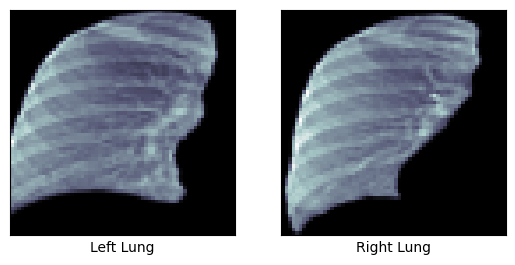

In [3]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(1,2,1)
plt.setp(ax.get_xticklabels(),visible=(False))
plt.setp(ax.get_yticklabels(),visible=(False))
ax.imshow(lungl[0][0],cmap="bone")
ax.set_xlabel('Left Lung')
ax.tick_params(axis='both', which='both', length=0)

ax2 = fig.add_subplot(1,2,2)
plt.setp(ax2.get_xticklabels(),visible=(False))
plt.setp(ax2.get_yticklabels(),visible=(False))
# ax2.imshow(np.flip(lung_r, axis=1),cmap="bone")
ax2.imshow(lungr[0][0],cmap="bone")

ax2.set_xlabel('Right Lung')
ax2.tick_params(axis='both', which='both', length=0)

## Create Siamese Adapted Dataset

In [4]:
class SiameseDataset(Dataset):
    """
    Adapter custom lung pair dataset to work with siamese network training
    Converts lung image pairs into positive/negative pairs for contrastive learning
    """
    def __init__(self, lung_dataset, negative_sampling_ratio=1.0):
        """
        Args:
            lung_dataset: Your ImagePairDataset instance
            negative_sampling_ratio: Ratio of negative to positive pairs
        """
        self.lung_dataset = lung_dataset
        self.negative_sampling_ratio = negative_sampling_ratio
        self.pairs = []
        self._create_training_pairs()
        
    def _create_training_pairs(self):
        """Create positive and negative pairs for training"""
        all_data = []
        
        # Collect all individual images with their class info
        for idx in range(len(self.lung_dataset)):
            lungl, lungr, class_idx, lungl_path, lungr_path = self.lung_dataset[idx]
            
            all_data.append({
                'image': lungl,
                'class_idx': class_idx,
                'path': lungl_path,
                'pair_idx': idx,
                'side': 'left'
            })
            all_data.append({
                'image': lungr,
                'class_idx': class_idx,
                'path': lungr_path,
                'pair_idx': idx,
                'side': 'right'
            })
        
        # Create positive pairs (same class)
        positive_pairs = []
        for i in range(len(all_data)):
            for j in range(i + 1, len(all_data)):
                if all_data[i]['class_idx'] == all_data[j]['class_idx']:
                    positive_pairs.append((i, j, 1.0))  # label 1 for match
        
        # Create negative pairs (different class)
        negative_pairs = []
        num_negatives = int(len(positive_pairs) * self.negative_sampling_ratio)
        
        attempts = 0
        while len(negative_pairs) < num_negatives and attempts < num_negatives * 10:
            i = np.random.randint(0, len(all_data))
            j = np.random.randint(0, len(all_data))
            
            if i != j and all_data[i]['class_idx'] != all_data[j]['class_idx']:
                if (i, j, 0.0) not in negative_pairs and (j, i, 0.0) not in negative_pairs:
                    negative_pairs.append((i, j, 0.0))  # label 0 for no match
            attempts += 1
        
        # Combine and shuffle
        self.pairs = positive_pairs + negative_pairs
        np.random.shuffle(self.pairs)
        self.all_data = all_data
        
        print(f"Created {len(positive_pairs)} positive pairs and {len(negative_pairs)} negative pairs")
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        i, j, label = self.pairs[idx]
        img1 = self.all_data[i]['image']
        img2 = self.all_data[j]['image']
        return img1, img2, torch.tensor(label, dtype=torch.float32)


## Defining Super Network

### Siamese-Style Network

This network expects to recieve pre-trained ResNet50 models, truncated to Layer 8, outputting `(2048)` embeddings. 

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
import numpy as np

class SiameseNetwork(nn.Module):
    """
    Siamese-style network for pair-wise contrastive learning
    Expects truncated to Layer 8 (2048,) pre-trained ResNet50 backbones
    """
    def __init__(self, pretrained_backbone, embedding_dim=128, freeze_backbone=False):
        super(SiameseNetwork, self).__init__()
        
        self.backbone = pretrained_backbone
        
        backbone_dim = 2048
        
        self.embedding_head = nn.Sequential(
            nn.Linear(backbone_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, embedding_dim)
        )
        
        # L2 normalisation layer
        self.l2_norm = nn.functional.normalize
        
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
        
    # def forward_one(self, x):
    #     """Forward pass for one image"""
    #     features = self.backbone(x)  # Output: (batch_size, 2048)
    #     embedding = self.embedding_head(features)  # Output: (batch_size, embedding_dim)
    #     return F.normalize(embedding, p=2, dim=1)  # L2 normalise
    def forward_one(self, x):
        """Forward pass for one image"""
        features = self.backbone(x)  # Output: (batch_size, 2048)
        if features.dim() == 4:
            # Ensure global pooling to 1x1 then flatten to (B, 2048)
            if features.shape[-1] != 1 or features.shape[-2] != 1:
                features = F.adaptive_avg_pool2d(features, output_size=1)
            features = torch.flatten(features, 1)
        embedding = self.embedding_head(features)  # Output: (batch_size, embedding_dim)
        return F.normalize(embedding, p=2, dim=1)  # L2 normalize
    
    def forward(self, x1, x2):
        """Forward pass for image pairs (lung_l, lung_r)"""
        emb1 = self.forward_one(x1)
        emb2 = self.forward_one(x2)
        return emb1, emb2

### Defining Loss Function

In [6]:
class ContrastiveLoss(nn.Module):
    """
    Standard contrastive loss for siamese networks
    Supports both euclidean (classic) and cosine distance
    Note: L2 Norm may work better with margin = 0.5 and cosine distance
    """
    def __init__(self, margin=1.0, distance='euclidean'):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin
        self.distance = distance
        
    def forward(self, emb1, emb2, labels):
        """
        Args:
            emb1, emb2: L2-normalised embeddings from siamese network
            labels: 1 for 'nodule' (no match), 0 for 'normal' (match)
        """
        if self.distance == 'euclidean':
            distance = F.pairwise_distance(emb1, emb2, p=2)
        elif self.distance == 'cosine':
            # Cosine distance = 1 - cosine similarity
            # For L2-normalised vectors: cosine_sim = dot_product
            cosine_sim = torch.sum(emb1 * emb2, dim=1)
            distance = 1 - cosine_sim
        else:
            raise ValueError(f"Unknown distance metric: {self.distance}")
        
        # Invert labels: 0='normal' should be pulled together, 1='nodule' pushed apart
        # (1-labels) to convert: 0->1 (attract), 1->0 (repel)
        positive_pairs = (1 - labels)  # normal pairs should be close
        negative_pairs = labels        # nodule pairs should be far
        
        loss = torch.mean(
            positive_pairs * torch.pow(distance, 2) +  # Pull normal pairs together
            negative_pairs * torch.pow(torch.clamp(self.margin - distance, min=0.0), 2)  # Push nodule pairs apart
        )
        return loss

## Initialising Backbones


In [7]:
import torch
import torchvision
from torchvision.models import resnet50
# add parent dir for loading helpers
import sys
sys.path.insert(1, '../')
import helpers

In [8]:
# RGB ImageNet
rgb_weights = torch.load("../models/rgb_3c_model_89.pth", map_location='cpu', weights_only=False)
rgb_model = torchvision.models.get_model("resnet50", weights=None, num_classes=1000)
rgb_model.load_state_dict(rgb_weights["model"])
rgb_model = torch.nn.Sequential(*list(rgb_model.children())[:9])

# Greyscale ImageNet
grey_weights = torch.load("../models/grey_3c_model_89.pth", map_location='cpu', weights_only=False)
grey_model = torchvision.models.get_model("resnet50", weights=None, num_classes=1000)
grey_model.load_state_dict(grey_weights["model"])
grey_model = torch.nn.Sequential(*list(grey_model.children())[:9])

# Single-Channel ImageNet
# load weights
single_weights = torch.load("../models/grey_1c_model_89.pth", map_location='cpu', weights_only=False)
single_model = torchvision.models.get_model("resnet50", weights=None, num_classes=1000)
single_model = helpers.models.convert_to_single_channel(single_model)
single_model.load_state_dict(single_weights["model"])
single_model = torch.nn.Sequential(*list(single_model.children())[:9])

# RadImageNet
from helpers import radimagenet
from torch import nn

radimagenet_model = radimagenet.RadImageNetBackbone()
# radimagenet_classifier = radimagenet.RadImageNetClassifier(num_class=1)

radimagenet_model.load_state_dict(torch.load("../models/radimagenet_resnet50.pt"))
radimagenet_model = torch.nn.Sequential(*list(radimagenet_model.children())[:9])
# radimagenet_classifier = RadImageNetClassifier(num_class=num_class)
# radimagenet_comparable = nn.Sequential(radimagenet_backbone, radimagenet_classifier)

/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


## Initialise Dataloader

In [9]:
resize_dim=224 #224
from torchvision import transforms
base_transform = transforms.Compose([
    transforms.Resize((resize_dim, resize_dim)),
    transforms.ToTensor(),
])

# Augmentation for contrastive learning
augment_transform = transforms.Compose([
    transforms.Resize((resize_dim, resize_dim)),
    transforms.RandomRotation(degrees=15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

from torchvision.transforms import v2 as v2transforms
randomaugs = [
    v2transforms.ToImage(),
    v2transforms.Resize(size=[resize_dim*2]),  # Slightly larger for random crops
    v2transforms.RandomResizedCrop(resize_dim, scale=(0.6, 1.0), ratio=(0.8, 1.2)),
    v2transforms.RandomHorizontalFlip(p=0.5),
    v2transforms.RandomRotation(degrees=10),
    v2transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.1, hue=0.05),
    v2transforms.RandomApply([
        v2transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))
    ], p=0.3),
    v2transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
    v2transforms.ToDtype(torch.float32, scale=True),  # Scale to [0,1] first
]

In [10]:
dataset_path = "../split_node21"
process = "lung_seg" #"crop" "arch_seg"
bsz = 64
# Load with default settings
train_dataloader = load_image_pair_dataset(
    dataset_path=os.path.join(dataset_path, process, "train"),
    batch_size=bsz,
    crop_size=resize_dim,  # Standard ResNet50 input size
    symmetrical_transforms=True,
    class_to_idx={'nodule': 1, 'normal': 0},
    transform=augment_transform

)

# Load with default settings
test_dataloader = load_image_pair_dataset(
    dataset_path=os.path.join(dataset_path, process, "test"),
    batch_size=bsz,
    crop_size=resize_dim,  # Standard ResNet50 input size
    symmetrical_transforms=True,
    class_to_idx={'nodule': 1, 'normal': 0},
    transform=base_transform
)

Loading dataset: 100%|██████████| 2/2 [00:00<00:00, 13.66it/s]


Total pairs: 2581
Number of classes: 2
Class mapping: {'nodule': 1, 'normal': 0}

Pairs per class:
  nodule (idx=1): 742
  normal (idx=0): 1839


Loading dataset: 100%|██████████| 2/2 [00:00<00:00,  2.60it/s]

Total pairs: 1107
Number of classes: 2
Class mapping: {'nodule': 1, 'normal': 0}

Pairs per class:
  nodule (idx=1): 318
  normal (idx=0): 789


In [11]:
# dataset_path = "../split_node21"
# process = "lung_seg" #"crop" "arch_seg"
# symmetrical_transforms = True
# bsz = 64
# image_names=('lung_l.png', 'lung_r.png')
# class_to_idx={'nodule': 1, 'normal': 0}


# train_dataset = ImagePairDataset(
#         root=os.path.join(dataset_path, process, "train"),
#         transform=augment_transform,
#         symmetrical_transforms=symmetrical_transforms,
#         image_names=image_names,
#         class_to_idx=class_to_idx
#     )

# test_dataset = ImagePairDataset(
#         root=os.path.join(dataset_path, process, "test"),
#         transform=base_transform,
#         symmetrical_transforms=True,
#         image_names=image_names,
#         class_to_idx=class_to_idx
#     )

In [12]:
# train_siamese_dataset = SiameseDataset(train_dataset, negative_sampling_ratio=1.0)
# test_siamese_dataset = SiameseDataset(test_datalset, negative_sampling_ratio=1.0)

## Basic Training Loop

##### Unfrozen Backbone With Eucludian Loss

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

siamese_rgb_model = SiameseNetwork(rgb_model, embedding_dim=128, freeze_backbone=False).to(device)

contrastive_loss = ContrastiveLoss(margin=1.0)
optimizer = torch.optim.Adam(siamese_rgb_model.parameters(), lr=0.001)



In [14]:
def train_siamese_epoch(model, dataloader, criterion, optimizer, device):
    """Training loop for siamese network"""
    model.train()
    total_loss = 0
    
    for batch_idx, (img1, img2, labels, path1, path2) in enumerate(dataloader):
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
        
        optimizer.zero_grad()
        emb1, emb2 = model(img1, img2)
        loss = criterion(emb1, emb2, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # if batch_idx % 100 == 0:
        #     print(f'Batch {batch_idx}, Loss: {loss.item():.4f}')
    
    return total_loss / len(dataloader)


In [26]:
# unfrozen backbone
for epoch in range(0,100):
    avg_loss = train_siamese_epoch(siamese_rgb_model, train_dataloader, contrastive_loss, optimizer, device)
    print(f"Epoch {epoch}, Average Loss: {avg_loss:.4f}")

Epoch 0, Average Loss: 0.2119
Epoch 1, Average Loss: 0.2091
Epoch 2, Average Loss: 0.2108
Epoch 3, Average Loss: 0.2086
Epoch 4, Average Loss: 0.2064
Epoch 5, Average Loss: 0.2090
Epoch 6, Average Loss: 0.2075
Epoch 7, Average Loss: 0.2074
Epoch 8, Average Loss: 0.2083
Epoch 9, Average Loss: 0.2066
Epoch 10, Average Loss: 0.2082
Epoch 11, Average Loss: 0.2089
Epoch 12, Average Loss: 0.2065
Epoch 13, Average Loss: 0.2071
Epoch 14, Average Loss: 0.2076
Epoch 15, Average Loss: 0.2049
Epoch 16, Average Loss: 0.2085
Epoch 17, Average Loss: 0.2089
Epoch 18, Average Loss: 0.2099
Epoch 19, Average Loss: 0.2070
Epoch 20, Average Loss: 0.2083
Epoch 21, Average Loss: 0.2077
Epoch 22, Average Loss: 0.2052
Epoch 23, Average Loss: 0.2062
Epoch 24, Average Loss: 0.2067
Epoch 25, Average Loss: 0.2080


KeyboardInterrupt: 

##### Frozen Backbone With Cosine Loss

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

siamese_rgb_model = SiameseNetwork(rgb_model, embedding_dim=128, freeze_backbone=True).to(device)

contrastive_loss = ContrastiveLoss(margin=1.0, distance="cosine")
optimizer = torch.optim.Adam(siamese_rgb_model.parameters(), lr=0.001)



In [ ]:
#frozen RGB backbone - COSINE
for epoch in range(0,100):
    avg_loss = train_siamese_epoch(siamese_rgb_model, train_dataloader, contrastive_loss, optimizer, device)
    print(f"Epoch {epoch}, Average Loss: {avg_loss:.4f}")

Epoch 0, Average Loss: 0.2262
Epoch 1, Average Loss: 0.2127
Epoch 2, Average Loss: 0.2140
Epoch 3, Average Loss: 0.2085
Epoch 4, Average Loss: 0.2200
Epoch 5, Average Loss: 0.2067
Epoch 6, Average Loss: 0.2149
Epoch 7, Average Loss: 0.2053
Epoch 8, Average Loss: 0.2034
Epoch 9, Average Loss: 0.2056
Epoch 10, Average Loss: 0.2066
Epoch 11, Average Loss: 0.1964
Epoch 12, Average Loss: 0.2084
Epoch 13, Average Loss: 0.2002
Epoch 14, Average Loss: 0.2037
Epoch 15, Average Loss: 0.1989
Epoch 16, Average Loss: 0.1984
Epoch 17, Average Loss: 0.1966
Epoch 18, Average Loss: 0.1949
Epoch 19, Average Loss: 0.1978
Epoch 20, Average Loss: 0.1968
Epoch 21, Average Loss: 0.1928
Epoch 22, Average Loss: 0.1991
Epoch 23, Average Loss: 0.1908
Epoch 24, Average Loss: 0.1940
Epoch 25, Average Loss: 0.1919
Epoch 26, Average Loss: 0.1936
Epoch 27, Average Loss: 0.1917
Epoch 28, Average Loss: 0.1955
Epoch 29, Average Loss: 0.1917
Epoch 30, Average Loss: 0.1961
Epoch 31, Average Loss: 0.1884
Epoch 32, Average 